# Визуальный EDA курсов ЦБ РФ

Целевые коридоры: **AMD, KGS, KZT, TJS, UZS**; контекст: **USD, EUR, CNY**. `rub_per_unit` — рублей за единицу иностранной валюты: снижение выгодно отправителю рублей.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
from IPython.display import clear_output, display

plt.style.use('seaborn-v0_8-whitegrid')
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
files = list((ROOT / 'data' / 'processed').glob('cbr_fx_daily_*.csv'))
DATA = max(files, key=lambda p: p.stat().st_size)
raw = pd.read_csv(DATA, parse_dates=['date']).sort_values(['currency', 'date'])
print(f'{DATA.name}: {len(raw):,} строк, {raw.date.min().date()} — {raw.date.max().date()}')

Matplotlib is building the font cache; this may take a moment.


cbr_fx_daily_2010-01-01_2026-09-02.csv: 32,932 строк, 2010-01-01 — 2026-09-02


## Срез данных

Измените год или список валют, затем в следующей ячейке с графиком нажмите **Run All Below**. Не перезапускайте ячейку с виджетами: она создаст их заново со значениями по умолчанию. Для выбора нескольких валют используйте `⌘` + клик.

In [2]:
years = sorted(raw.date.dt.year.unique())
all_currencies = sorted(raw.currency.unique())
start_year = widgets.SelectionSlider(
    options=years, value=years[0], description='С какого года:',
    continuous_update=False, style={'description_width': 'initial'},
)
currency_picker = widgets.SelectMultiple(
    options=all_currencies, value=tuple(all_currencies), rows=len(all_currencies),
    description='Валюты:', style={'description_width': 'initial'},
)
display(widgets.HBox([start_year, currency_picker]))

def selected_view():
    chosen = list(currency_picker.value)
    return raw[(raw.date.dt.year >= start_year.value) & raw.currency.isin(chosen)].copy()

view = selected_view()
levels = view.pivot(index='date', columns='currency', values='rub_per_unit').sort_index()
log_returns = np.log(levels).diff()
shown = list(levels.columns)

## Общая динамика

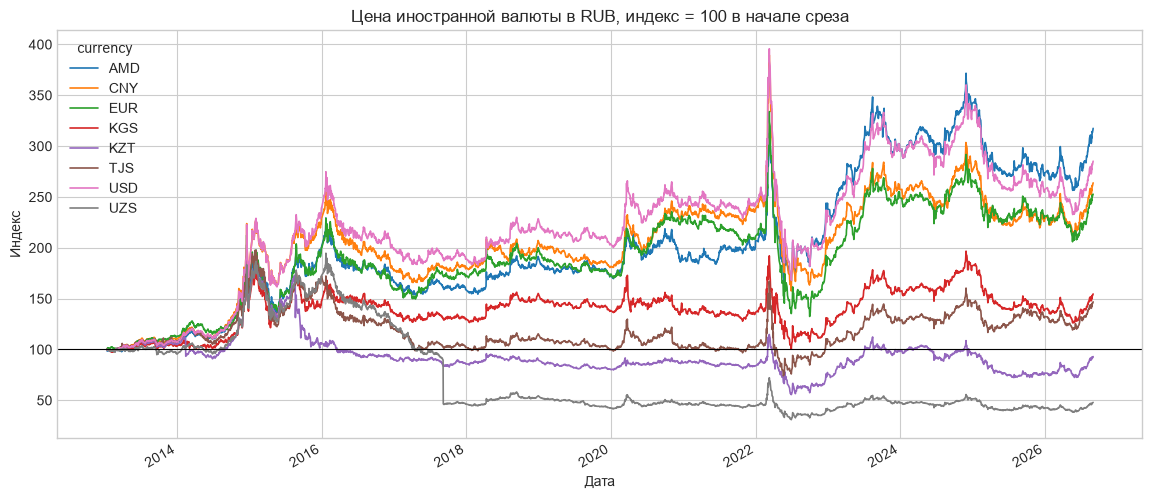

In [3]:
# Повторно читаем текущее состояние виджетов при каждом запуске этой ячейки.
view = selected_view()
levels = view.pivot(index='date', columns='currency', values='rub_per_unit').sort_index()
log_returns = np.log(levels).diff()
shown = list(levels.columns)

indexed = levels.apply(lambda s: s / s.dropna().iloc[0] * 100)
ax = indexed.plot(figsize=(14, 6), linewidth=1.2)
ax.axhline(100, color='black', linewidth=.8)
ax.set(title='Цена иностранной валюты в RUB, индекс = 100 в начале среза', xlabel='Дата', ylabel='Индекс')
plt.show()

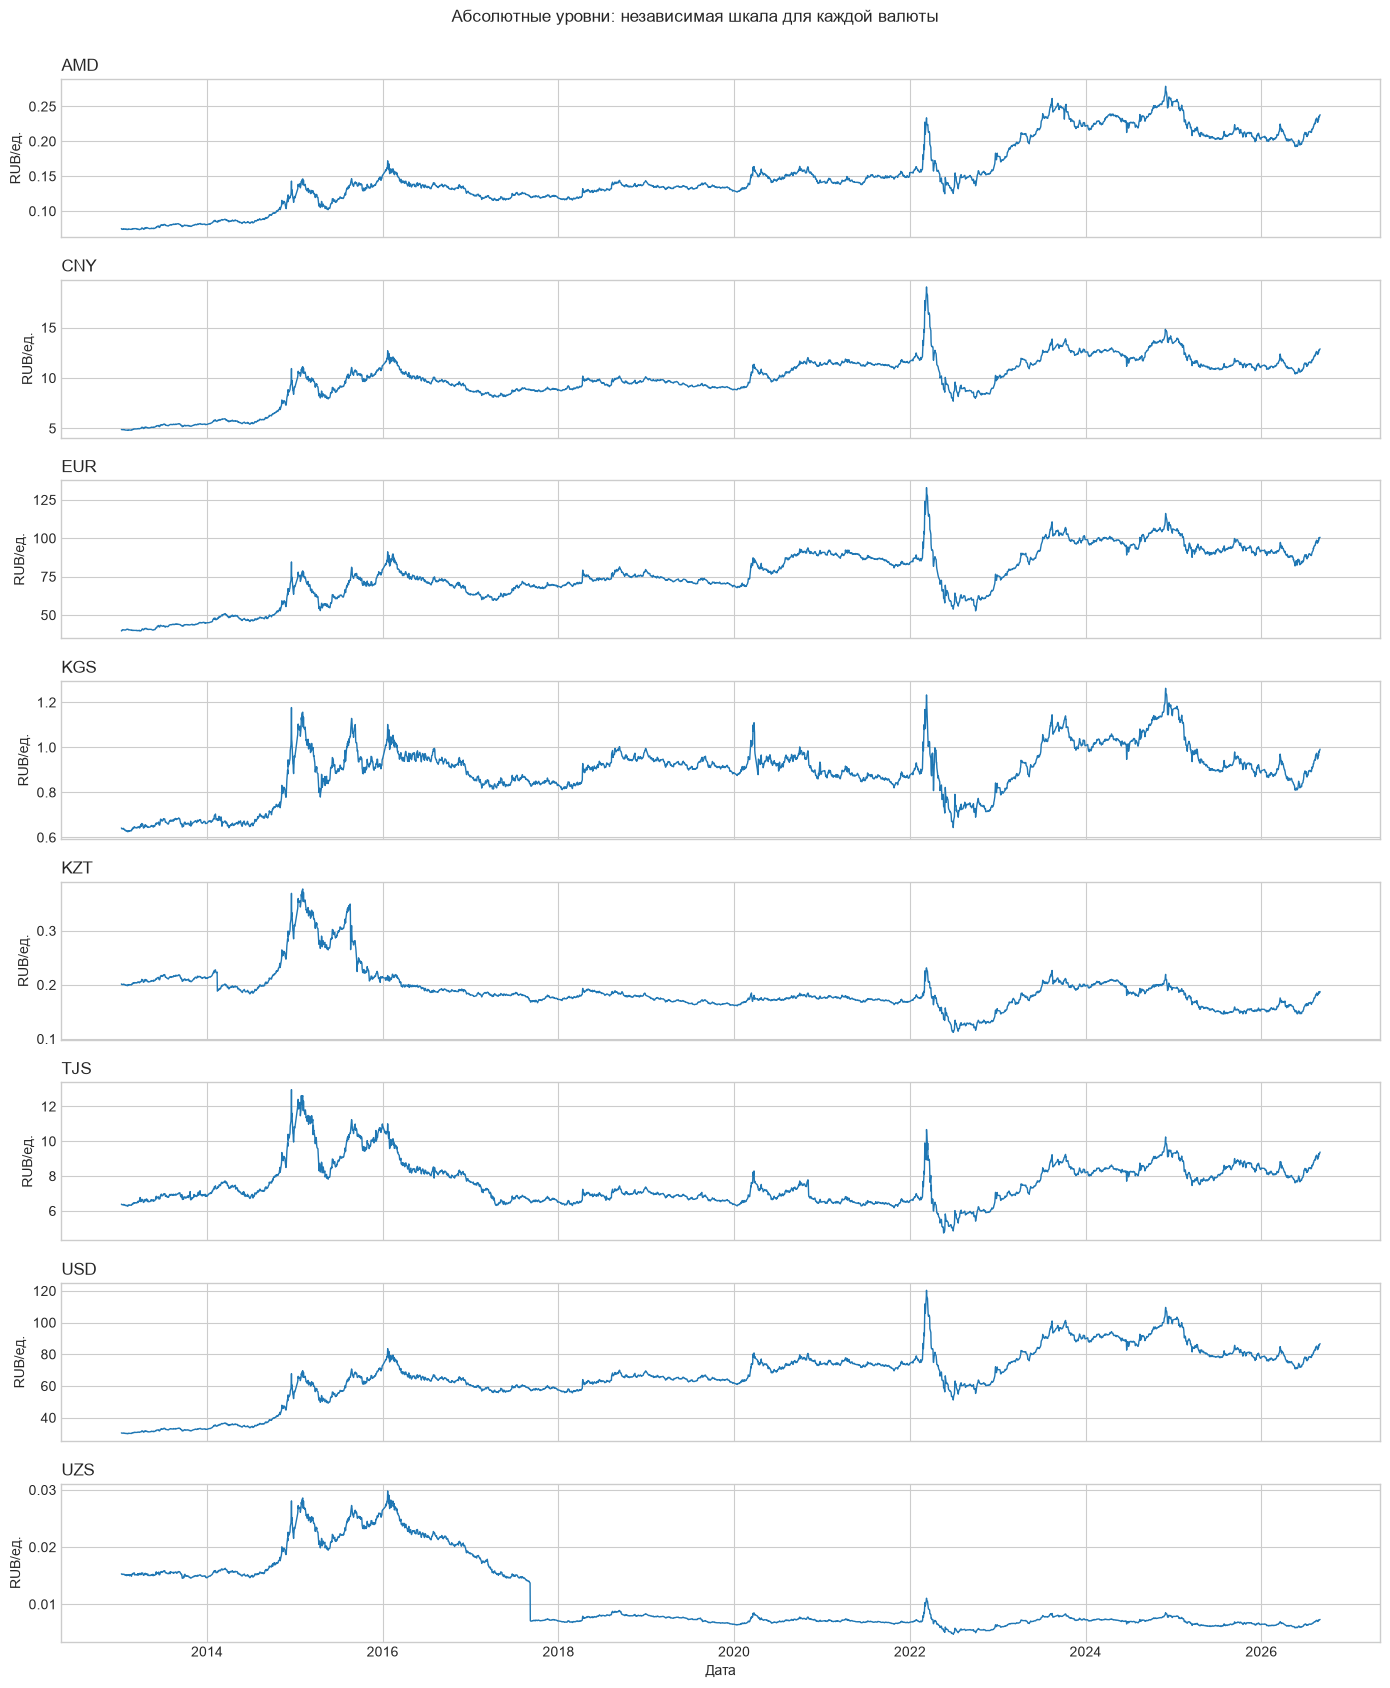

In [4]:
shown = list(levels.columns)
fig, axes = plt.subplots(len(shown), 1, figsize=(14, max(4, 2.1 * len(shown))), sharex=True, squeeze=False)
for ax, currency in zip(axes.flat, shown):
    ax.plot(levels.index, levels[currency], linewidth=1)
    ax.set_title(currency, loc='left')
    ax.set_ylabel('RUB/ед.')
axes.flat[-1].set_xlabel('Дата')
fig.suptitle('Абсолютные уровни: независимая шкала для каждой валюты', y=1.002)
plt.tight_layout()
plt.show()

## Масштаб обычных и месячных движений

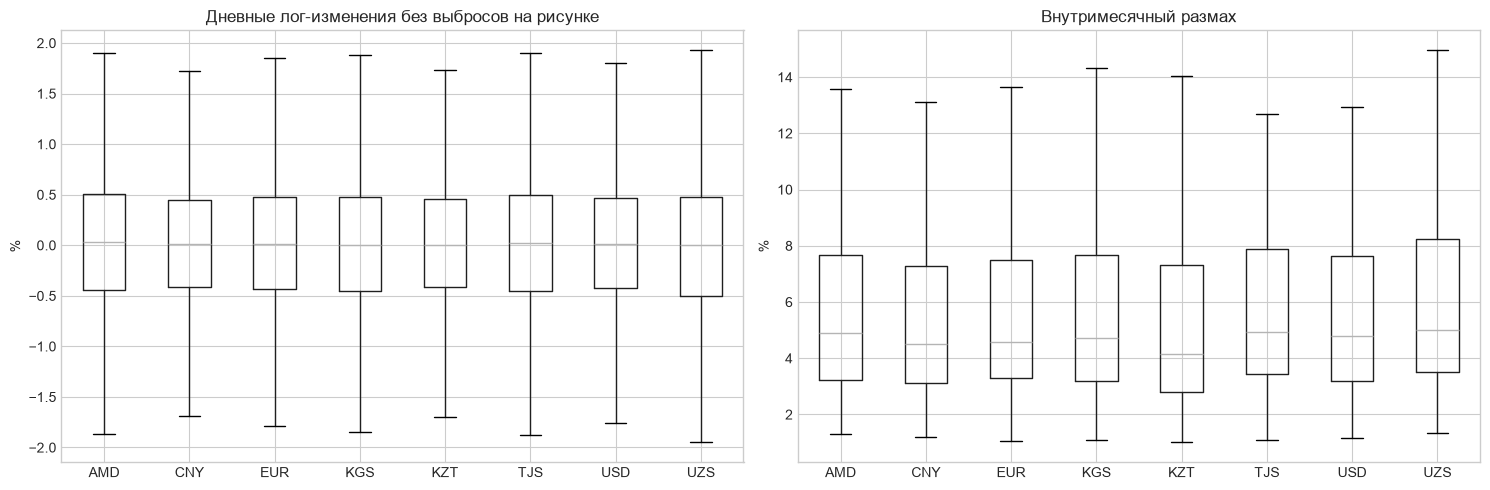

In [5]:
daily_pct = log_returns * 100
monthly = (
    view.assign(month=view.date.dt.to_period('M'))
    .groupby(['currency', 'month']).rub_per_unit.agg(['min', 'max', 'count'])
    .query('count >= 10').assign(range_pct=lambda x: (x['max'] / x['min'] - 1) * 100)
    .reset_index()
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
daily_pct.boxplot(ax=axes[0], showfliers=False)
axes[0].set(title='Дневные лог-изменения без выбросов на рисунке', ylabel='%')
monthly.pivot(columns='currency', values='range_pct').boxplot(ax=axes[1], showfliers=False)
axes[1].set(title='Внутримесячный размах', ylabel='%')
plt.tight_layout()
plt.show()

## Общий рублёвый фактор

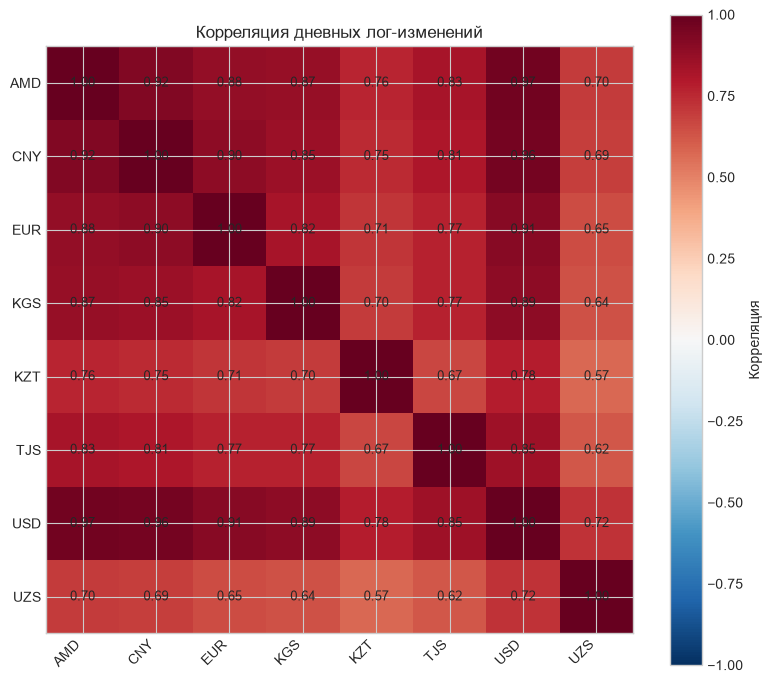

In [6]:
corr = log_returns.corr()
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(image, ax=ax, label='Корреляция')
ax.set_title('Корреляция дневных лог-изменений')
plt.tight_layout()
plt.show()

## Режимы волатильности

Сплошная линия быстро реагирует на шок; пунктирная MAD-оценка показывает фоновый шум и почти не реагирует на одиночный выброс. Разрыв между ними указывает на jump-компоненту.

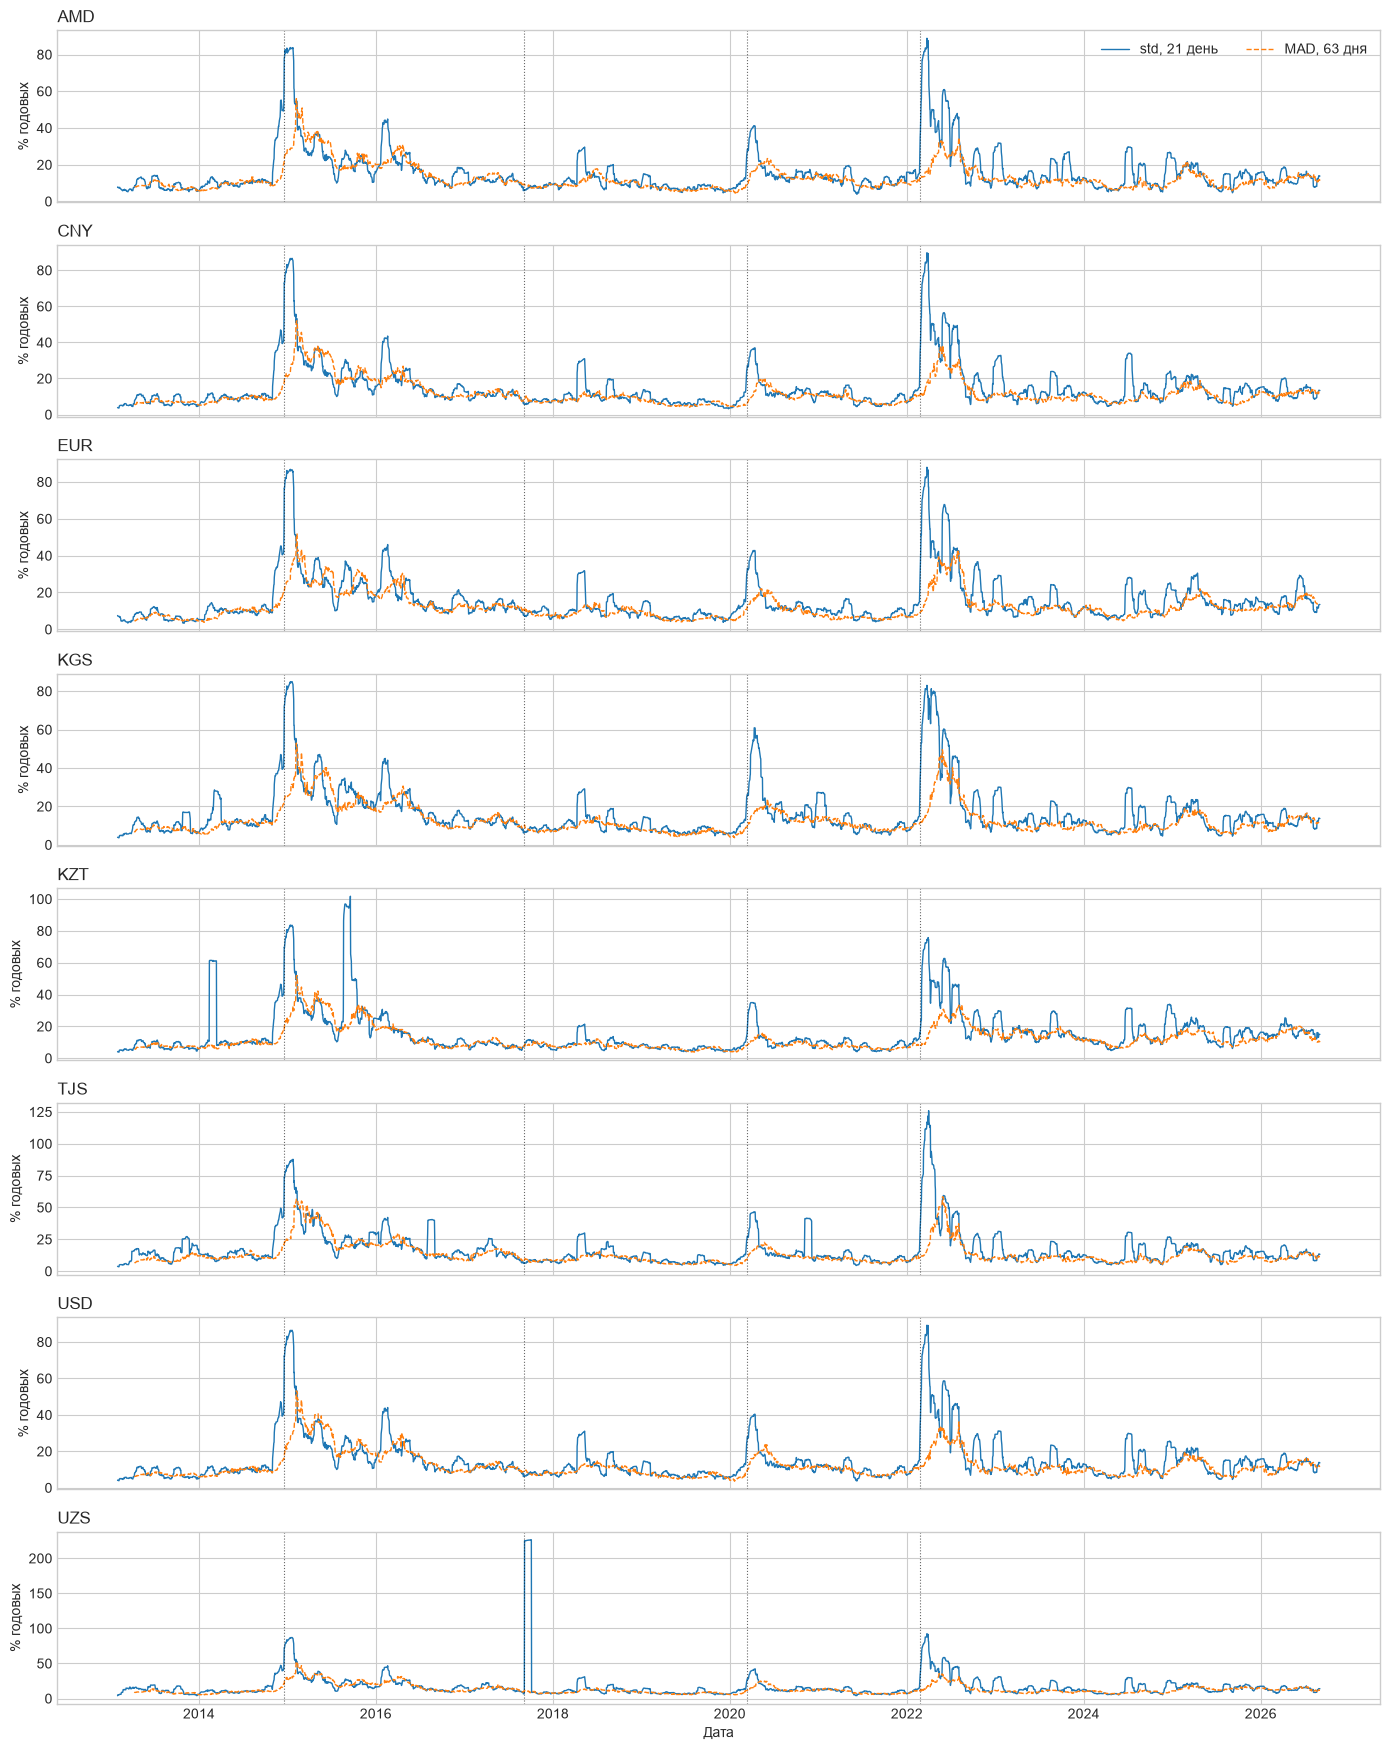

In [7]:
EVENTS = {
    '2014': pd.Timestamp('2014-12-16'),
    'UZS 2017': pd.Timestamp('2017-09-05'),
    'COVID': pd.Timestamp('2020-03-11'),
    'Февраль 2022': pd.Timestamp('2022-02-24'),
}
vol_21 = log_returns.rolling(21, min_periods=14).std() * np.sqrt(252) * 100
mad_63 = log_returns.apply(lambda s: s.rolling(63, min_periods=40).apply(
    lambda x: 1.4826 * np.median(np.abs(x - np.median(x))), raw=True
)) * np.sqrt(252) * 100

fig, axes = plt.subplots(len(shown), 1, figsize=(14, max(4, 2.2 * len(shown))), sharex=True, squeeze=False)
for ax, currency in zip(axes.flat, shown):
    ax.plot(vol_21.index, vol_21[currency], label='std, 21 день', linewidth=1)
    ax.plot(mad_63.index, mad_63[currency], label='MAD, 63 дня', linewidth=1, linestyle='--')
    for event_date in EVENTS.values():
        if levels.index.min() <= event_date <= levels.index.max():
            ax.axvline(event_date, color='black', linestyle=':', linewidth=.8, alpha=.6)
    ax.set_title(currency, loc='left')
    ax.set_ylabel('% годовых')
axes.flat[0].legend(ncol=2, loc='upper right')
axes.flat[-1].set_xlabel('Дата')
plt.tight_layout()
plt.show()

## Направленный режим

Линия показывает $T_t=\sqrt{10}\,\bar r_{t,10}/s_{t,63}$. Значение выше нуля — иностранная валюта дорожает в рублях, ниже нуля — дешевеет. Красная и синяя заливки показывают направление; области за пунктирными уровнями ±2 считаем выраженным локальным движением.

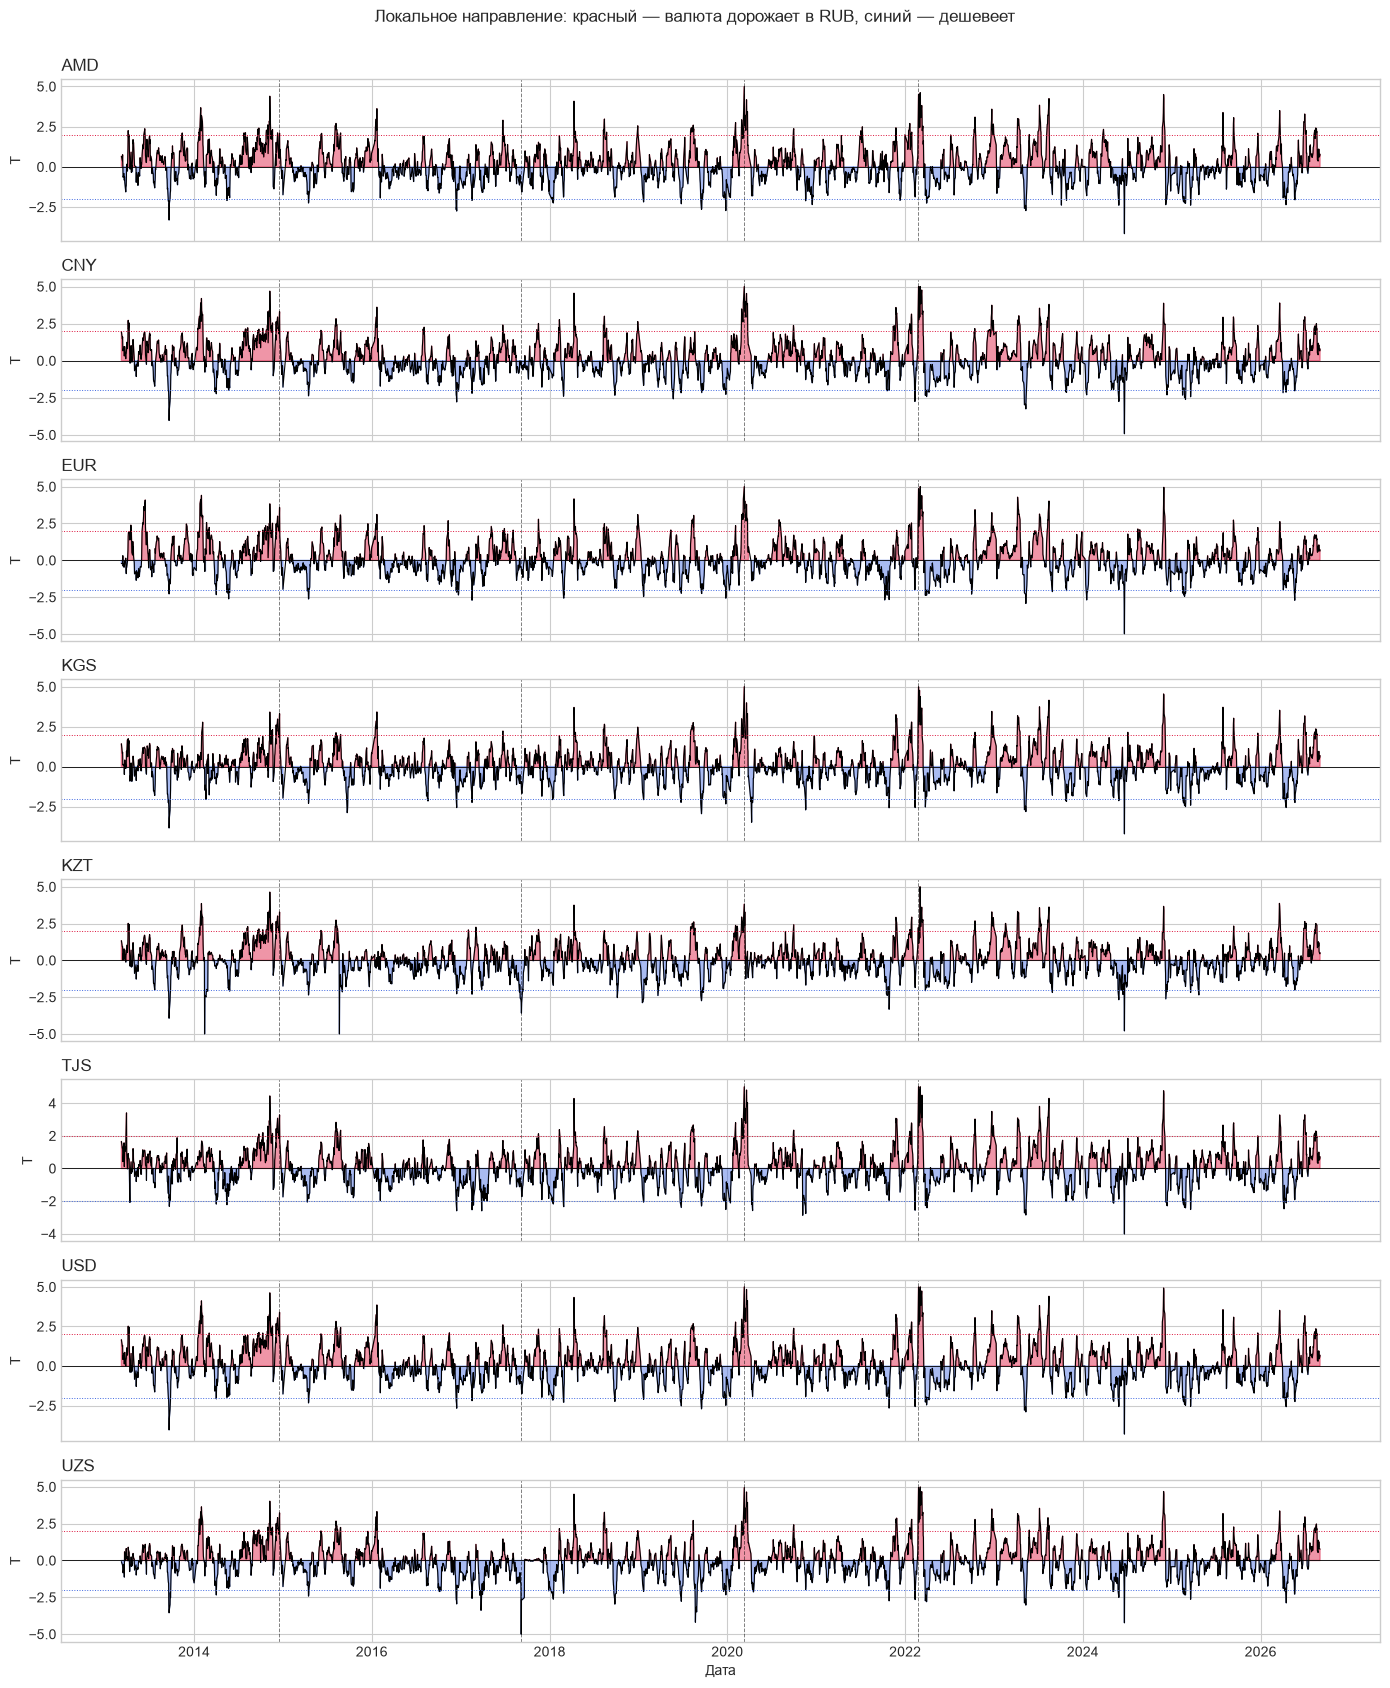

In [8]:
trend_score = (
    log_returns.rolling(10, min_periods=7).mean() * np.sqrt(10)
    / log_returns.rolling(63, min_periods=40).std().shift(1)
).clip(-5, 5)
fig, axes = plt.subplots(len(shown), 1, figsize=(14, max(4, 2.1 * len(shown))), sharex=True, squeeze=False)
for ax, currency in zip(axes.flat, shown):
    score = trend_score[currency]
    ax.plot(score.index, score, color='black', linewidth=.8)
    ax.fill_between(score.index, 0, score, where=score.ge(0), color='crimson', alpha=.45)
    ax.fill_between(score.index, 0, score, where=score.lt(0), color='royalblue', alpha=.45)
    ax.axhline(0, color='black', linewidth=.6)
    ax.axhline(2, color='crimson', linestyle=':', linewidth=.7)
    ax.axhline(-2, color='royalblue', linestyle=':', linewidth=.7)
    for event_date in EVENTS.values():
        if levels.index.min() <= event_date <= levels.index.max():
            ax.axvline(event_date, color='black', linestyle='--', linewidth=.7, alpha=.5)
    ax.set_title(currency, loc='left')
    ax.set_ylabel('T')
axes.flat[-1].set_xlabel('Дата')
fig.suptitle('Локальное направление: красный — валюта дорожает в RUB, синий — дешевеет', y=1.002)
plt.tight_layout()
plt.show()

## CUSUM без общего движения рубля

Обычный CUSUM повторял USD почти во всех строках, потому что все курсы выражены через RUB и содержат один общий рублёвый шок. Здесь он применяется к отношению `(RUB за локальную валюту) / (RUB за USD)`, то есть к локальной валюте против USD. `▲` отмечает её укрепление к USD, `▼` — ослабление.

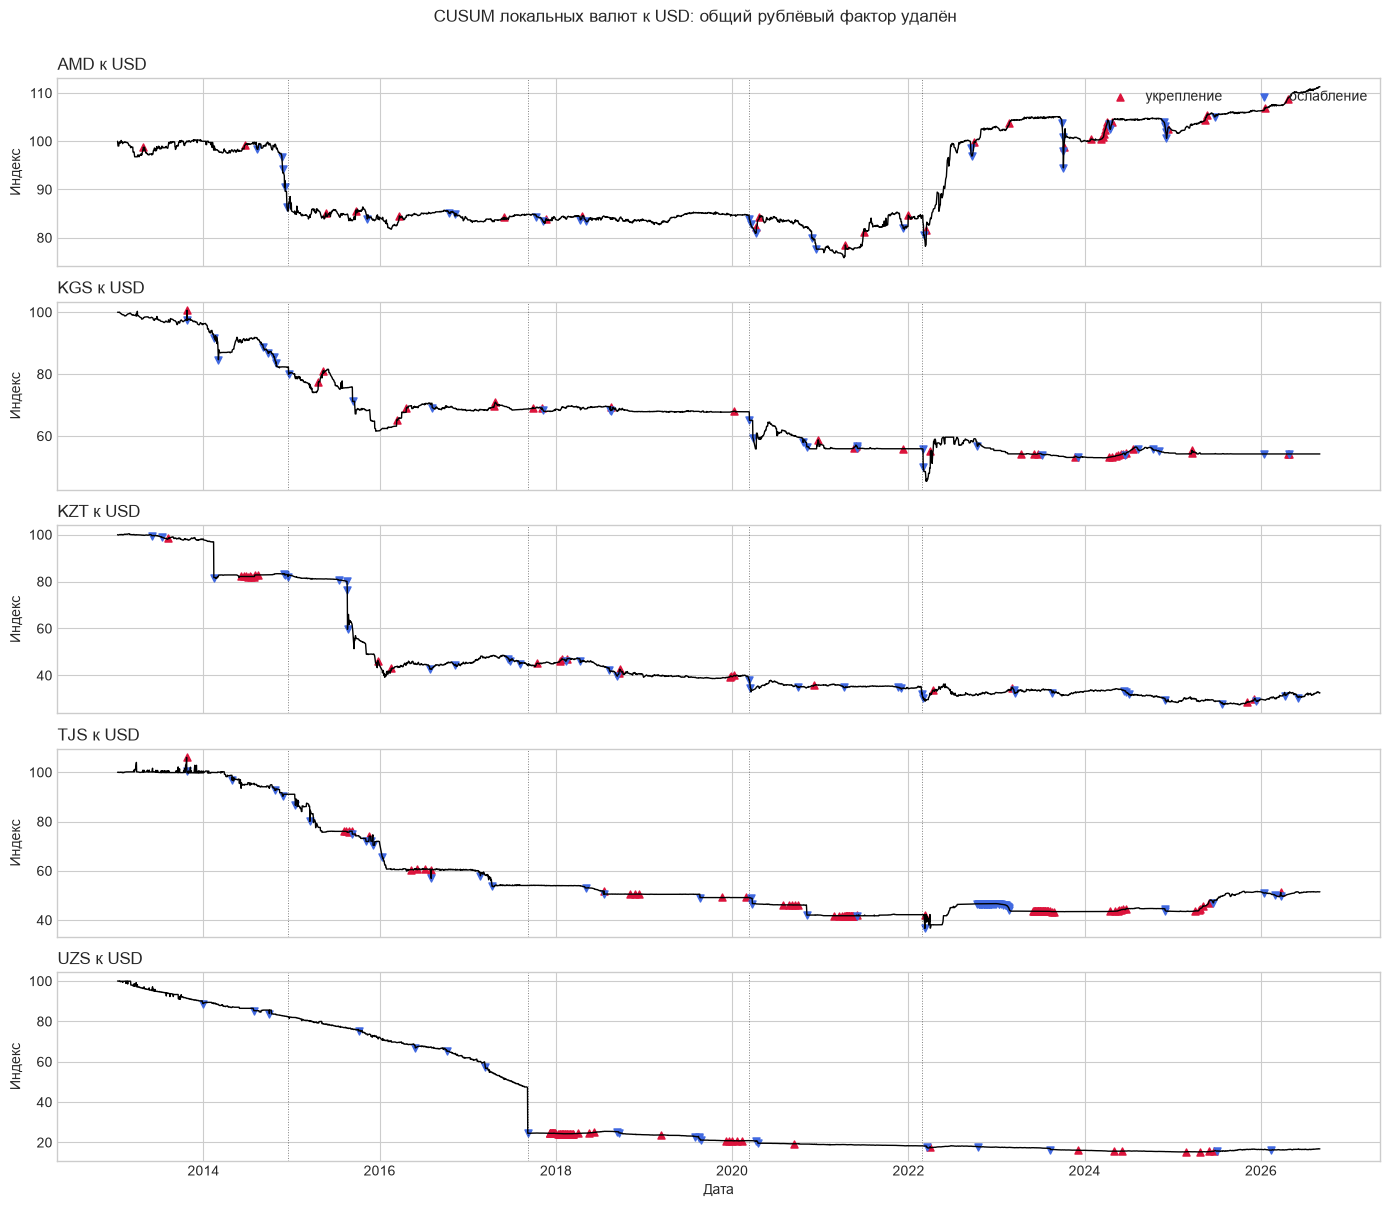

In [9]:
def cusum_alarms(z, threshold=6, allowance=.25):
    positive = negative = 0.0
    alarms = []
    for value in z:
        if pd.isna(value):
            alarms.append(0); continue
        positive = max(0, positive + value - allowance)
        negative = min(0, negative + value + allowance)
        alarm = 0
        if positive > threshold:
            alarm, positive, negative = 1, 0, 0
        elif negative < -threshold:
            alarm, positive, negative = -1, 0, 0
        alarms.append(alarm)
    return pd.Series(alarms, index=z.index)

all_targets = ['AMD', 'KGS', 'KZT', 'TJS', 'UZS']
target_currencies = [c for c in shown if c in all_targets] or all_targets
full_levels = raw[raw.date.dt.year >= start_year.value].pivot(
    index='date', columns='currency', values='rub_per_unit'
).sort_index()
usd_cross = full_levels[target_currencies].divide(full_levels['USD'], axis=0)

fig, axes = plt.subplots(len(target_currencies), 1, figsize=(14, max(4, 2.4 * len(target_currencies))), sharex=True, squeeze=False)
for ax, currency in zip(axes.flat, target_currencies):
    series = usd_cross[currency].dropna()
    r = np.log(series).diff()
    past_mean = r.rolling(126, min_periods=63).mean().shift(1)
    past_scale = r.rolling(63, min_periods=40).std().shift(1)
    z = (r - past_mean) / past_scale
    alarms = cusum_alarms(z, threshold=6)
    indexed_series = series / series.iloc[0] * 100
    up, down = alarms.eq(1), alarms.eq(-1)
    ax.plot(indexed_series.index, indexed_series, color='black', linewidth=1)
    ax.scatter(indexed_series.index[up], indexed_series[up], marker='^', color='crimson', s=26, label='укрепление')
    ax.scatter(indexed_series.index[down], indexed_series[down], marker='v', color='royalblue', s=26, label='ослабление')
    for event_date in EVENTS.values():
        if series.index.min() <= event_date <= series.index.max():
            ax.axvline(event_date, color='black', linestyle=':', linewidth=.7, alpha=.5)
    ax.set_title(f'{currency} к USD', loc='left')
    ax.set_ylabel('Индекс')
axes.flat[0].legend(ncol=2, loc='upper right')
axes.flat[-1].set_xlabel('Дата')
fig.suptitle('CUSUM локальных валют к USD: общий рублёвый фактор удалён', y=1.002)
plt.tight_layout()
plt.show()

## Автоматический поиск смены режима

Сравниваем последние 21 наблюдение с предшествующими 252 сразу по всем выбранным валютам. Верхняя панель разделяет сдвиг среднего и дисперсии, нижняя показывает их совместную норму. Красная область означает превышение адаптивного 99%-порога, рассчитанного только по прошлым значениям статистики.

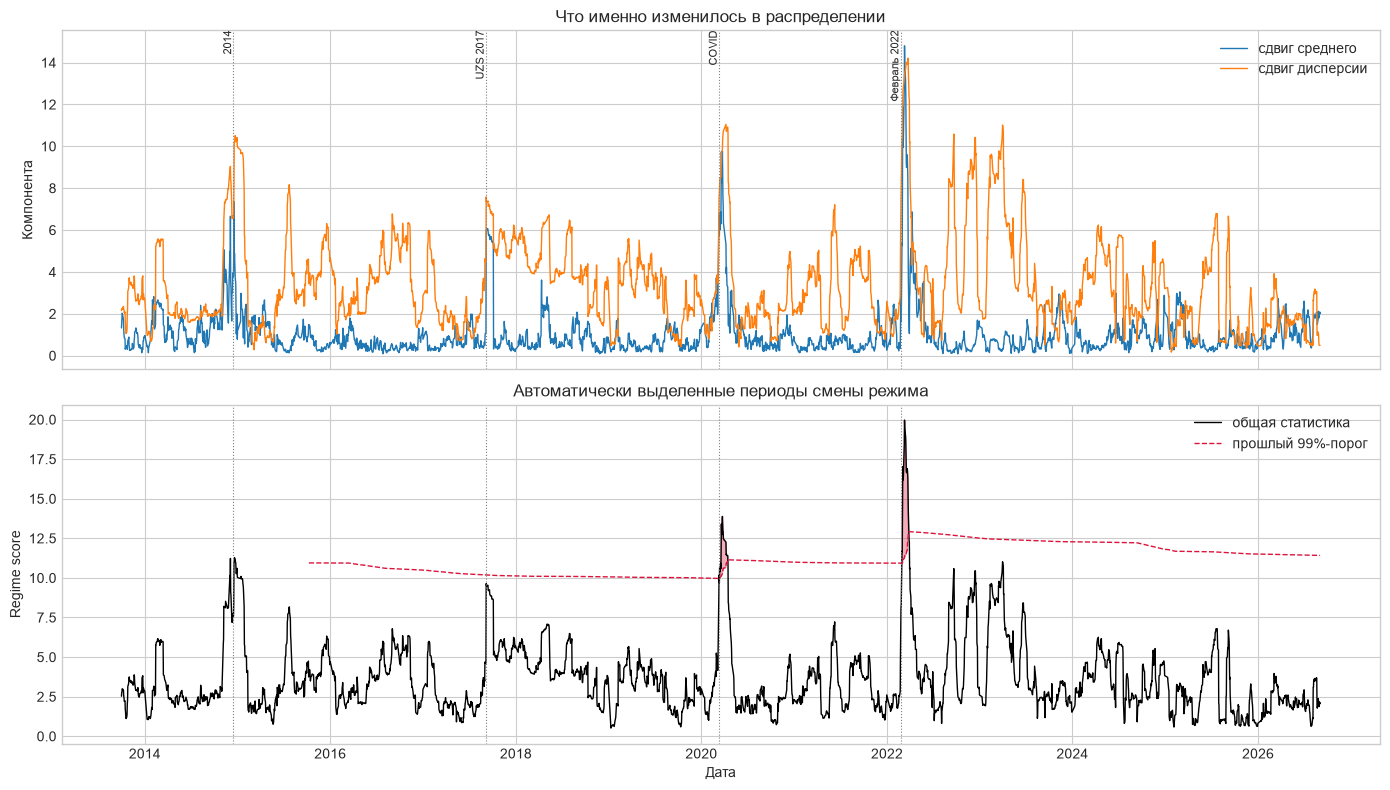

In [10]:
recent_mean = log_returns.rolling(21, min_periods=15).mean()
recent_var = log_returns.rolling(21, min_periods=15).var()
baseline_mean = log_returns.shift(21).rolling(252, min_periods=160).mean()
baseline_var = log_returns.shift(21).rolling(252, min_periods=160).var()

mean_shift = np.sqrt(21) * np.sqrt(
    (((recent_mean - baseline_mean) / np.sqrt(baseline_var)) ** 2).mean(axis=1)
)
variance_shift = np.sqrt(21 / 2) * np.sqrt(
    (np.log(recent_var / baseline_var) ** 2).mean(axis=1)
)
regime_score = np.sqrt(mean_shift ** 2 + variance_shift ** 2)
adaptive_threshold = regime_score.shift(1).expanding(min_periods=500).quantile(.99)
is_regime_change = regime_score > adaptive_threshold

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(mean_shift, label='сдвиг среднего', linewidth=1)
axes[0].plot(variance_shift, label='сдвиг дисперсии', linewidth=1)
axes[0].set(ylabel='Компонента', title='Что именно изменилось в распределении')
axes[0].legend()
axes[1].plot(regime_score, color='black', linewidth=1, label='общая статистика')
axes[1].plot(adaptive_threshold, color='crimson', linestyle='--', linewidth=1, label='прошлый 99%-порог')
axes[1].fill_between(regime_score.index, adaptive_threshold, regime_score, where=is_regime_change, color='crimson', alpha=.35)
axes[1].set(ylabel='Regime score', xlabel='Дата', title='Автоматически выделенные периоды смены режима')
axes[1].legend()
for ax in axes:
    for label, event_date in EVENTS.items():
        if levels.index.min() <= event_date <= levels.index.max():
            ax.axvline(event_date, color='grey', linestyle=':', linewidth=.8)
            if ax is axes[0]:
                ax.text(event_date, ax.get_ylim()[1], label, rotation=90, va='top', ha='right', fontsize=8)
plt.tight_layout(); plt.show()

## Локальный уровень и тренд: фильтр Калмана

Работаем с логарифмом курса $y_t$ и моделью локального линейного тренда:

$$y_t = \mu_t + \varepsilon_t, \qquad \mu_t = \mu_{t-1} + \beta_{t-1} + \eta_t, \qquad \beta_t = \beta_{t-1} + \zeta_t.$$

$\mu_t$ — скрытый локальный уровень, $\beta_t$ — его текущий наклон. Перед появлением курса за день $t$ фильтр переносит вчерашний уровень вперёд на величину наклона: $\hat\mu_{t|t-1}=\hat\mu_{t-1|t-1}+\hat\beta_{t-1|t-1}$. Разность между опубликованным курсом и этим прогнозом называется **инновацией**. Затем фильтр поправляет уровень и наклон: чем больше неопределённость прогноза относительно шума наблюдения, тем больше коэффициент Калмана и тем сильнее поправка.

Как читать панели:

1. **Наблюдение и локальный уровень.** Серый — фактический `rub_per_unit`, нормированный к 100 в начале среза; чёрный — так же нормированная оценка $\mu_t$. Расхождение показывает краткосрочное движение, которое фильтр ещё не признал устойчивым.
2. **Локальный наклон.** Это $\beta_t$ в basis points за одно опубликованное наблюдение. Красный — иностранная валюта систематически дорожает в RUB; синий — дешевеет, что выгоднее отправителю рублей. Серая полоса — условный 95%-интервал неопределённости наклона.
3. **Стандартизированная инновация.** Это однодневная ошибка прогноза, делённая на её ожидаемое стандартное отклонение. Значение $+4$ означает, что курс оказался выше прогноза примерно на четыре ожидаемых сигмы. Выход за $\pm3$ отмечает неожиданный шок, но сам по себе ещё не доказывает смену тренда.

Фильтр односторонний: прогноз для даты $t$ строится до загрузки $y_t$. Масштаб шума адаптируется только по уже наблюдавшимся доходностям. Фиксированные отношения дисперсий задают степень сглаживания и позднее должны настраиваться внутри walk-forward, а не на полном ряду. На итоговой сетке строки соответствуют шести разным валютам (`USD` и пяти целевым коридорам), а три столбца — описанным выше величинам. Год берётся из верхнего виджета при запуске ячейки.

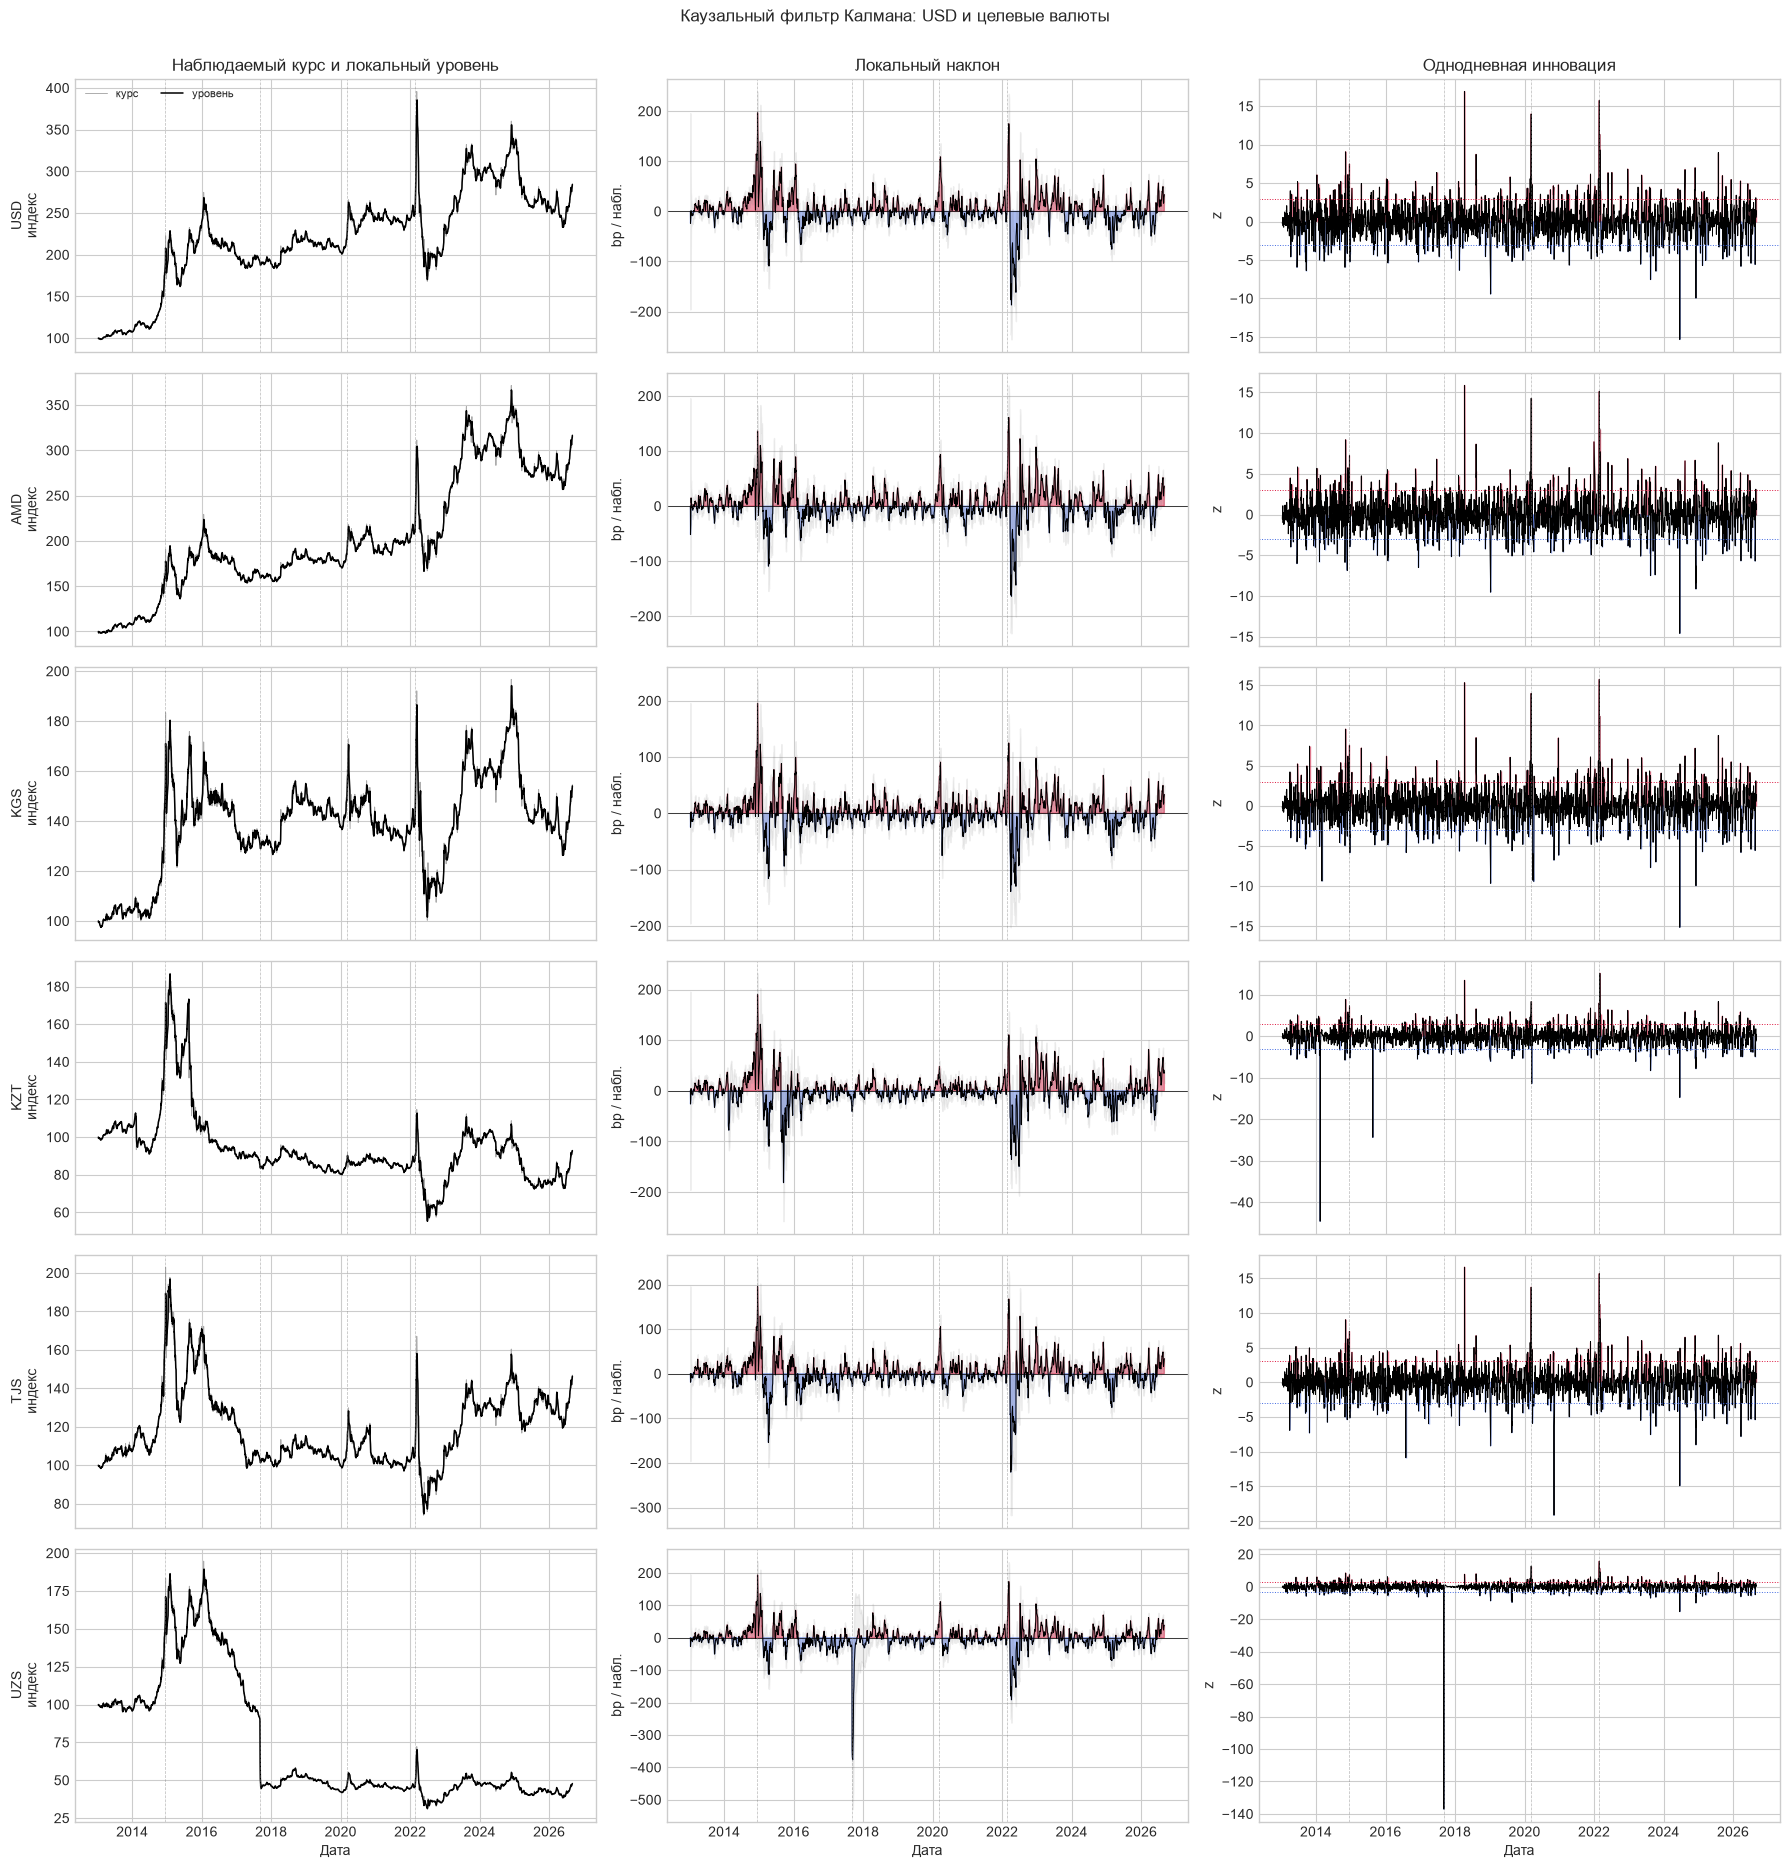

In [11]:
def causal_local_linear_trend(series, memory=63):
    y = np.log(series.dropna()).to_numpy()
    index = series.dropna().index
    n = len(y)
    if n < 2:
        return pd.DataFrame(index=index, columns=['level', 'slope', 'slope_se', 'innovation_z'])

    # x_t = (local level, local slope); one step = one published CBR observation.
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([1.0, 0.0])
    x = np.array([y[0], 0.0])
    online_var = 1e-4  # causal initial scale: daily volatility of roughly 1%
    P = online_var * np.diag([10.0, 1.0])
    alpha = 2 / (memory + 1)

    level = np.full(n, np.nan)
    slope = np.full(n, np.nan)
    slope_se = np.full(n, np.nan)
    innovation_z = np.full(n, np.nan)
    level[0], slope[0], slope_se[0] = x[0], x[1], np.sqrt(P[1, 1])

    for t in range(1, n):
        # At this point online_var contains information only through t-1.
        scale = max(online_var, 1e-8)
        Q = scale * np.diag([0.05, 0.001])
        R = 0.25 * scale
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q
        innovation = y[t] - H @ x_pred
        innovation_var = H @ P_pred @ H + R
        innovation_z[t] = innovation / np.sqrt(innovation_var)
        K = (P_pred @ H) / innovation_var
        x = x_pred + K * innovation
        P = (np.eye(2) - np.outer(K, H)) @ P_pred
        P = (P + P.T) / 2
        level[t], slope[t], slope_se[t] = x[0], x[1], np.sqrt(max(P[1, 1], 0))

        observed_return = y[t] - y[t - 1]
        online_var = (1 - alpha) * online_var + alpha * observed_return ** 2

    return pd.DataFrame({
        'level': level, 'slope': slope, 'slope_se': slope_se,
        'innovation_z': innovation_z,
    }, index=index)

def plot_local_trend_grid(year, currencies):
    plt.close('all')
    fig, axes = plt.subplots(len(currencies), 3, figsize=(18, 3.1 * len(currencies)),
                             sharex='col', squeeze=False)
    axes[0, 0].set_title('Наблюдаемый курс и локальный уровень')
    axes[0, 1].set_title('Локальный наклон')
    axes[0, 2].set_title('Однодневная инновация')

    for row, currency in enumerate(currencies):
        series = (raw[(raw.currency == currency) & (raw.date.dt.year >= year)]
                  .set_index('date').rub_per_unit.sort_index())
        state = causal_local_linear_trend(series)
        observed_index = series / series.iloc[0] * 100
        filtered_index = np.exp(state.level - np.log(series.iloc[0])) * 100
        slope_bp = state.slope * 10_000
        slope_band = 1.96 * state.slope_se * 10_000
        z = state.innovation_z

        level_ax, slope_ax, innovation_ax = axes[row]
        level_ax.plot(observed_index, color='grey', linewidth=.7, alpha=.65, label='курс')
        level_ax.plot(filtered_index, color='black', linewidth=1.1, label='уровень')
        level_ax.set_ylabel(f'{currency}\nиндекс')

        slope_ax.plot(slope_bp.index, slope_bp, color='black', linewidth=.7)
        slope_ax.fill_between(slope_bp.index, 0, slope_bp, where=slope_bp.ge(0), color='crimson', alpha=.45)
        slope_ax.fill_between(slope_bp.index, 0, slope_bp, where=slope_bp.lt(0), color='royalblue', alpha=.45)
        slope_ax.fill_between(slope_bp.index, slope_bp - slope_band, slope_bp + slope_band,
                              color='grey', alpha=.12)
        slope_ax.axhline(0, color='black', linewidth=.5)
        slope_ax.set_ylabel('bp / набл.')

        innovation_ax.plot(z.index, z, color='black', linewidth=.65)
        innovation_ax.fill_between(z.index, 0, z, where=z.ge(3), color='crimson', alpha=.55)
        innovation_ax.fill_between(z.index, 0, z, where=z.le(-3), color='royalblue', alpha=.55)
        innovation_ax.axhline(3, color='crimson', linestyle=':', linewidth=.7)
        innovation_ax.axhline(-3, color='royalblue', linestyle=':', linewidth=.7)
        innovation_ax.set_ylabel('z')

        for ax in axes[row]:
            for event_date in EVENTS.values():
                if series.index.min() <= event_date <= series.index.max():
                    ax.axvline(event_date, color='grey', linestyle='--', linewidth=.55, alpha=.5)

    axes[0, 0].legend(loc='upper left', ncol=2, fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel('Дата')
    fig.suptitle('Каузальный фильтр Калмана: USD и целевые валюты', y=1.002)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

kalman_currencies = ['USD', 'AMD', 'KGS', 'KZT', 'TJS', 'UZS']
plot_local_trend_grid(start_year.value, kalman_currencies)

## Локальный спектральный анализ

Обычный Fourier-спектр теряет время события. Поэтому используем непрерывное wavelet-преобразование общего стандартизованного валютного фактора. Яркая вертикальная область означает всплеск энергии сразу на нескольких временных масштабах; шкала по вертикали — характерная длительность в опубликованных днях.

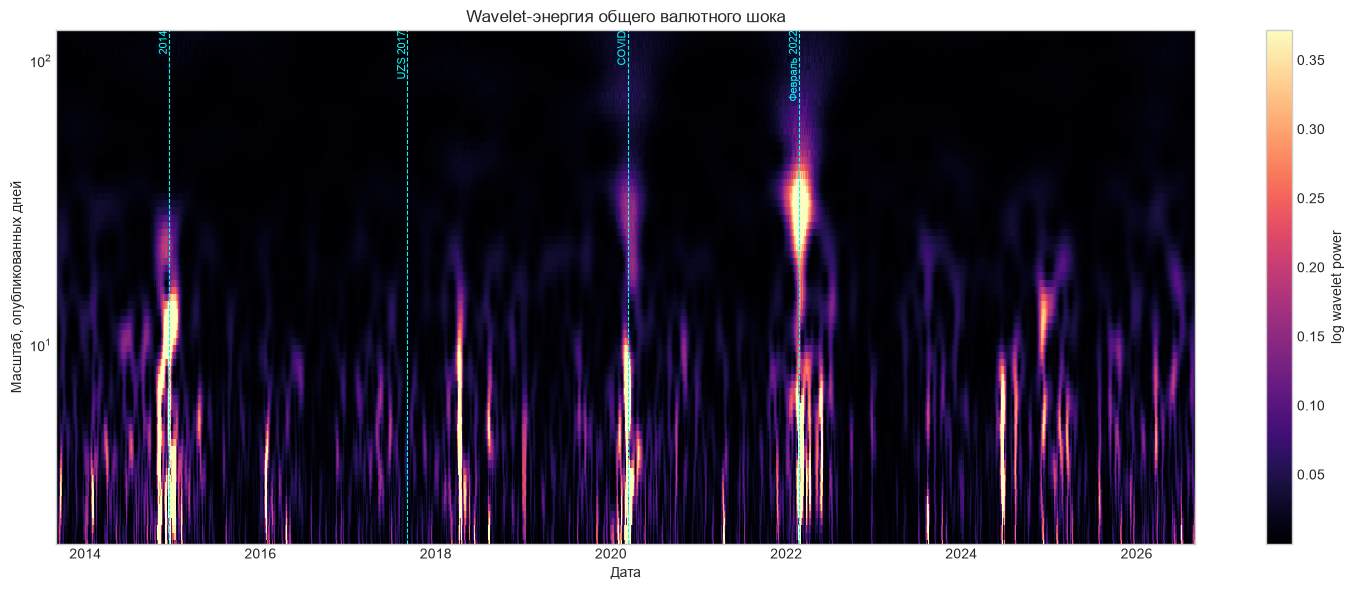

In [12]:
past_mean = log_returns.rolling(252, min_periods=160).mean().shift(1)
past_std = log_returns.rolling(252, min_periods=160).std().shift(1)
standardized_returns = (log_returns - past_mean) / past_std
common_factor = standardized_returns.median(axis=1).dropna()
scales = np.geomspace(2, 128, 72)
coefficients, frequencies = pywt.cwt(common_factor.to_numpy(), scales, 'cmor1.5-1.0')
periods = 1 / frequencies
log_power = np.log1p(np.abs(coefficients) ** 2 / scales[:, None])

fig, ax = plt.subplots(figsize=(15, 6))
mesh = ax.pcolormesh(common_factor.index, periods, log_power, shading='auto', cmap='magma', vmax=np.quantile(log_power, .99))
ax.set_yscale('log')
ax.set_ylim(periods.min(), periods.max())
for label, event_date in EVENTS.items():
    if common_factor.index.min() <= event_date <= common_factor.index.max():
        ax.axvline(event_date, color='cyan', linestyle='--', linewidth=.8)
        ax.text(event_date, periods.max(), label, rotation=90, va='top', ha='right', color='cyan', fontsize=8)
fig.colorbar(mesh, ax=ax, label='log wavelet power')
ax.set(title='Wavelet-энергия общего валютного шока', xlabel='Дата', ylabel='Масштаб, опубликованных дней')
plt.tight_layout(); plt.show()

Regime score использует только текущие и прошлые данные; его порог также строится по прошлому. Wavelet-карта симметрична по времени и годится только для EDA: в рабочий сигнал её нельзя переносить без односторонней causal-версии. Все пороги далее нужно проверять walk-forward.